[WiDS 2025 | Baseline](https://www.kaggle.com/code/thiagomantuani/wids-2025-baseline)

[kaggle the Engineer Way](https://towardsdatascience.com/how-to-kaggle-the-engineer-way-act-1-vs-code-containers-b3279970c029)

In [1]:
import numpy as np 
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score
import lightgbm as lgb, xgboost as xgb, catboost as cb
from gc import collect
import os
import matplotlib.pyplot as plt
import umap
from matplotlib.ticker import MaxNLocator
import scipy
import seaborn as sns
from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures, MinMaxScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_curve, make_scorer
from sklearn.feature_selection import RFECV, SequentialFeatureSelector, SelectKBest
from sklearn.linear_model import LogisticRegression, RidgeClassifier,RidgeClassifierCV
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier
from sklearn.metrics import r2_score
from sklearn.manifold import TSNE


# Load Data

In [2]:
print(os.getcwd())

c:\Users\alan.mcdonagh\OneDrive - Milliman Inc\Projects\51. WiDS Datathon 2025\wids_2025_study


In [3]:
fpath_input = os.path.abspath('data')
print(fpath_input)

c:\Users\alan.mcdonagh\OneDrive - Milliman Inc\Projects\51. WiDS Datathon 2025\wids_2025_study\data


In [4]:

def get_feats(mode='TRAIN_OLD'):
    """
    Load data for the specified mode (TRAIN_OLD, TRAIN_NEW or TEST).
    """
    print(f"Loading {mode} data...")

    kw_suffix = {
        'TRAIN_OLD' : '',
        'TRAIN_NEW' : '_new',
        'TEST'      : ''
    }
    suffix = kw_suffix[mode]

    # Load quantitative metadata
    feats = pd.read_excel(f"{fpath_input}\\{mode}\\{mode[:5]}_QUANTITATIVE_METADATA{suffix}.xlsx")
    
    # Load categorical metadata
    if mode in ['TRAIN_OLD', 'TRAIN_NEW']:
        cate = pd.read_excel(f"{fpath_input}\\{mode}\\TRAIN_CATEGORICAL_METADATA{suffix}.xlsx")
    else:
        cate = pd.read_excel(f"{fpath_input}\\{mode}\\TEST_CATEGORICAL.xlsx")
    
    # Merge quantitative and categorical data
    feats = pd.merge(
        feats, 
        cate, 
        on  = 'participant_id', 
        how = 'left'
    )
    
    # Load functional connectome matrices
    if mode in ['TRAIN_OLD', 'TEST']:
        func = pd.read_csv(f"{fpath_input}\\{mode}\\{mode[:5]}_FUNCTIONAL_CONNECTOME_MATRICES.csv")
    else:
        func = pd.read_csv(f"{fpath_input}\\{mode}\\{mode[:5]}_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")


    feats = pd.merge(
        feats, 
        func, 
        on  = 'participant_id', 
        how = 'left'
    )
    
    # Load training solutions (only for TRAIN mode)
    if mode in ['TRAIN_OLD', 'TRAIN_NEW']:
        solution = pd.read_excel(f"{fpath_input}\\{mode}\\TRAINING_SOLUTIONS.xlsx")
        feats = pd.merge(
            feats, 
            solution, 
            on  = 'participant_id', 
            how = 'left'
        )
    
    return feats

# Load training and test data
train_old = get_feats(mode='TRAIN_OLD')
train_new = get_feats(mode='TRAIN_NEW')
test      = get_feats(mode='TEST'     )

# Display the first few rows of the training data
train_new.head()


Loading TRAIN_OLD data...
Loading TRAIN_NEW data...
Loading TEST data...


,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,...,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032,1,0
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,...,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978,1,0
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,...,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182,0,1
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,...,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613,0,1
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,...,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278,1,0


In [5]:
train = get_feats(mode='TRAIN_NEW')
test  = get_feats(mode='TEST')

Loading TRAIN_NEW data...
Loading TEST data...


In [6]:
fpath = f'{fpath_input}/SAMPLE_SUBMISSION.xlsx'
sub   = pd.read_excel(fpath)

fpath = f"{fpath_input}/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx"
y     = pd.read_excel(fpath)

train.set_index('participant_id',inplace=True)
test.set_index('participant_id',inplace=True)
targets = ['ADHD_Outcome','Sex_F']
features = test.columns

In [7]:
def check_for_nulls(df):
  """
  Checks for null values in a pandas DataFrame and prints a message.

  Args:
    df: The pandas DataFrame to check.

  Returns:
    None
  """
  if df.isnull().any().any():
    print("The DataFrame contains null values.")
  else:
    print("The DataFrame does not contain null values.")

In [8]:
check_for_nulls(train)
check_for_nulls(test)
print(f'Train: {train.shape}, Test: {test.shape}')

The DataFrame contains null values.
The DataFrame contains null values.
Train: (1213, 19929), Test: (304, 19927)


* We have many features...

# Target's

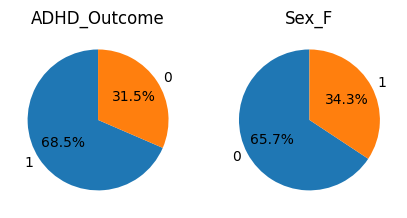

In [9]:
fig, axs = plt.subplots(1,2, figsize=(5,3))

for col, ax in zip(y.drop('participant_id',axis=1), axs):    
    counts = y[col].value_counts()
    ax.pie(counts, labels=counts.index, 
           autopct='%1.1f%%', 
           startangle=90)
    ax.set_title(f'{col}')

* We have a problem with unbalanced classes

# Model

* At first I will use a Ridge model

In [10]:
log_features = [f for f in features if (train[f] >= 0).all() and scipy.stats.skew(train[f]) > 0]

In [11]:
tup = train_test_split(
    train.drop(targets,axis=1), 
    y[targets], 
    test_size=0.80, # 0.30 was original
    random_state=42
)

X_train, X_test, y_train, y_test = tup


# Model Training and Evaluation

In this step, we train a Ridge Classifier model using a pipeline that includes data preprocessing steps such as imputation, logarithmic transformation, and scaling. The model is then evaluated using the F1 score.

- **MultiOutputClassifier**: This allows us to fit one classifier per target.
- **Pipeline**: Combines several preprocessing steps and the classifier into one.
    - **ColumnTransformer**: Applies different preprocessing steps to different columns.
        - **SimpleImputer**: Fills missing values.
        - **FunctionTransformer**: Applies a logarithmic transformation to specified features.
    - **MinMaxScaler**: Scales features to a given range.
    - **RidgeClassifier**: A linear classifier with L2 regularization.

The model is trained on the training data (`X_train`, `y_train`) and predictions are made on the test data (`X_test`). The performance is evaluated using the F1 score.


In [12]:


ct_1 = ColumnTransformer(
    transformers = [
        ('imputer', SimpleImputer(), features)
    ],
    remainder = 'passthrough',
    verbose_feature_names_out = False
)

ct_2 = ColumnTransformer(
    transformers = [
        ('log', FunctionTransformer(np.log1p), log_features)
    ],
    remainder = 'passthrough'
)

# *steps: list of Estimator objects
#     List of the scikit-learn estimators that are chained together.

steps = [
    ct_1.set_output(transform='pandas'), 
    ct_2,
    MinMaxScaler(),
    RidgeClassifier(alpha=100),
]

In [13]:
pipeline = make_pipeline(*steps)
pipeline

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  Index(['EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP',
       'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD',
       'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems',
       'SDQ_SDQ_Difficulties_Total',
       ...
       '195throw_196thcolu...
       '196throw_199thcolumn', '197throw_198thcolumn', '197throw_199thcolumn',
       '198throw_199thcolumn'],
      dtype='object', length=19927))],
                                   verbose_feature_names_out=False)),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['Basic_Demos_Study_Site'])])),
                ('minmaxscaler', MinMaxScaler()),
                ('ridgeclassifier', RidgeClassifier(alpha=100))])

In [14]:
model = MultiOutputClassifier(
    pipeline, 
    n_jobs=-1, # added this in to prevent crashing
)

In [15]:
print(
    f'X_train.shape = {X_train.shape}',
    f'y_train.shape = {y_train.shape}',
    sep='\n',
)

X_train.shape = (242, 19927)
y_train.shape = (242, 2)


In [16]:
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=Pipeline(steps=[('columntransformer-1',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('imputer',
                                                                                  SimpleImputer(),
                                                                                  Index(['EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP',
       'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD',
       'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems',
       'SDQ_SDQ_Difficulti...
       '196throw_199thcolumn', '197throw_198thcolumn', '197throw_199thcolumn',
       '198throw_199thcolumn'],
      dtype='object', length=19927))],
                                                                   verbose_feature_names_out=False)),
                                                ('columntransformer-2',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('log',
                                                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                                                  ['Basic_Demos_Study_Site'])])),
                                                ('minmaxscaler',
                                                 MinMaxScaler()),
                                                ('ridgeclassifier',
                                                 RidgeClassifier(alpha=100))]),
                      n_jobs=-1)

In [17]:
model.fit(
    X_train,
    y_train,
)

MultiOutputClassifier(estimator=Pipeline(steps=[('columntransformer-1',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('imputer',
                                                                                  SimpleImputer(),
                                                                                  Index(['EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP',
       'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD',
       'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems',
       'SDQ_SDQ_Difficulti...
       '196throw_199thcolumn', '197throw_198thcolumn', '197throw_199thcolumn',
       '198throw_199thcolumn'],
      dtype='object', length=19927))],
                                                                   verbose_feature_names_out=False)),
                                                ('columntransformer-2',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('log',
                                                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                                                  ['Basic_Demos_Study_Site'])])),
                                                ('minmaxscaler',
                                                 MinMaxScaler()),
                                                ('ridgeclassifier',
                                                 RidgeClassifier(alpha=100))]),
                      n_jobs=-1)

In [18]:
y_pred = model.predict(X_test)
print('f1: ', f1_score(y_test,y_pred,average='micro'))

f1:  0.603125


# Dimensionality reduction

## PCA

* PCA is particularly useful when dealing with high-dimensional datasets. We can try to improve our result by applying PCA
      

A pipeline in data science and machine learning is a structured sequence of steps designed to automate the process of preparing data, transforming it, and applying a model to make predictions. Think of it as an assembly line where raw data enters at one end, goes through a series of predefined operations, and comes out as a final result, such as predictions or insights.

As actuaries we can use a pipeline to preform the following steps in our analysis:

1. **Data Cleaning**: Handling missing values or correcting errors in the data.
2. **Feature Engineering**: Creating or transforming variables to better represent the underlying patterns.
3. **Scaling**: Standardizing numerical data to ensure consistency.
4. **Model Training**: Applying statistical or machine learning models to the data.
5. **Evaluation**: Assessing the model's performance using metrics like accuracy or F1 score.

By using a pipeline, we can ensure that their workflow is consistent, reproducible, and efficient, especially when working with large datasets or complex models.

In [19]:
# Define the steps for the pipeline

steps = [
    SimpleImputer(),  # Replace missing values with a default strategy (e.g., mean, median, or most frequent)
    StandardScaler(), # Standardize features by removing the mean and scaling to unit variance
    PCA()             # Perform Principal Component Analysis for dimensionality reduction
]

# Create a pipeline using the defined steps
pca = make_pipeline(*steps)


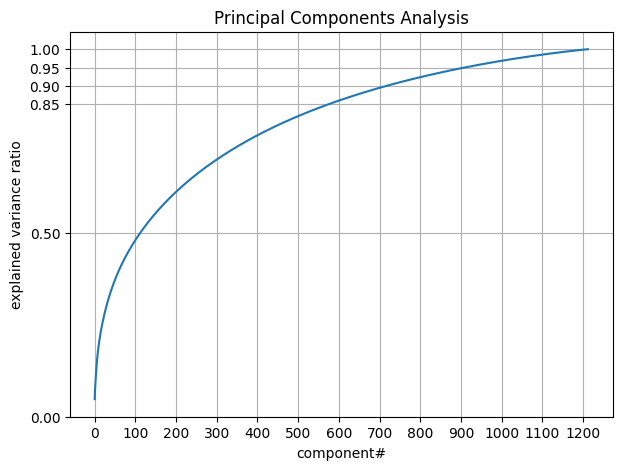

In [20]:
pca.fit(train[test.columns]) # Fit the PCA model using the features from the 'train' DataFrame

plt.figure(figsize=(7,5))  # Create a new figure with a specified size of 7x5 inches
plt.plot(pca[-1].explained_variance_ratio_.cumsum())  # Plot the cumulative sum of explained variance ratio for the PCA components
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Set the x-axis to display only integer values
plt.title('Principal Components Analysis')  # Set the title of the plot
plt.xlabel('component#')  # Label the x-axis as 'component#'
plt.ylabel('explained variance ratio')  # Label the y-axis as 'explained variance ratio'
plt.yticks([0,0.5,0.85,0.90,0.95,1])  # Set specific y-axis tick values for better visualization
plt.xticks(range(0,1300,100))  # Set x-axis ticks at intervals of 100 up to 1300
plt.grid()  # Add a grid to the plot for better readability
plt.show()  # Display the plot


## UMAP


## UMAP (Uniform Manifold Approximation and Projection)

UMAP is a dimensionality reduction technique that is particularly effective for visualizing high-dimensional data in a lower-dimensional space (e.g., 2D or 3D). It is based on manifold learning and is designed to preserve both the local and global structure of the data.

### Key Features of UMAP:
- **Preserves Local and Global Structure**: UMAP maintains the relationships between data points, making it suitable for clustering and visualization.
- **Scalable**: It can handle large datasets efficiently.
- **Flexible**: UMAP can be used for both supervised and unsupervised learning tasks.

### How UMAP Will Be Used:
In the following cell, UMAP will be applied to the scaled features of the training dataset (`train[features]`) to reduce the dimensionality to 2D. This will allow us to visualize the data in a two-dimensional space. The steps include:
1. **Preprocessing**: The features are scaled using a pipeline that includes `SimpleImputer` and `MinMaxScaler`.
2. **Fitting UMAP**: The UMAP model is trained on the scaled data.
3. **Visualization**: The transformed data is plotted in 2D, with points colored based on the target variables (`ADHD_Outcome` and `Sex_F`).

This visualization helps to understand the separability of the classes and the structure of the data in a reduced-dimensional space.


c:\Users\alan.mcdonagh\OneDrive - Milliman Inc\Projects\51. WiDS Datathon 2025\wids_2025_study\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\alan.mcdonagh\OneDrive - Milliman Inc\Projects\51. WiDS Datathon 2025\wids_2025_study\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Text(0.5, 0.98, 'UMAP')

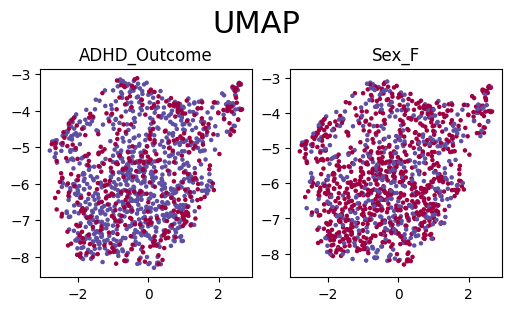

In [21]:
# Create a pipeline for preprocessing
pipe = make_pipeline(
    SimpleImputer(),  # Fill missing values with a default strategy (e.g., mean, median, or most frequent)
    MinMaxScaler()    # Scale features to a range between 0 and 1
)

# Initialize the UMAP dimensionality reduction model
reducer = umap.UMAP()

# Apply the preprocessing pipeline to the training dataset features
x_scaler = pipe.fit_transform(train[features])

# Fit the UMAP model to the scaled data
reducer.fit(x_scaler)

# Create a figure with 1 row and 2 columns of subplots
_, axs = plt.subplots(
    nrows=1,          # Number of rows in the subplot grid
    ncols=2,          # Number of columns in the subplot grid
    figsize=(5, 3),   # Size of the figure in inches (width, height)
    constrained_layout=True  # Automatically adjust subplot parameters for better layout
)

# Transform the scaled data into a lower-dimensional space using UMAP
embedding = reducer.transform(x_scaler)

# Loop through each target variable and corresponding subplot axis
for t, ax in zip(targets, axs.ravel()):    
    # Scatter plot of the UMAP embedding with points colored by the target variable
    ax.scatter(
        x=embedding[:, 0],  # First dimension of the UMAP embedding
        y=embedding[:, 1],  # Second dimension of the UMAP embedding
        c=y[t],             # Color points based on the target variable
        cmap='Spectral',    # Colormap for the scatter plot
        s=5                 # Size of the points in the scatter plot
    )
    # Set the aspect ratio of the plot to be equal
    plt.gca().set_aspect(
        aspect='equal',     # Equal scaling for x and y axes
        adjustable='datalim'  # Adjust axis limits to fit the data
    )
    # Set the title of the subplot to the name of the target variable
    ax.set_title(
        label=f'{t}'  # Title text
    )

# Set a title for the entire figure
plt.suptitle(
    t='UMAP',       # Title text
    fontsize=22     # Font size of the title
)

* For ADHD_Outcome, there is some separation between the groups, but there is also overlap.
* For Sex_F, there is also overlap between the groups.

# Submission

In [22]:
# Create a column transformer for imputing missing values
ct_1 = ColumnTransformer(
    [
        ('imputer', SimpleImputer(), features)  # Apply SimpleImputer to the specified features
    ],
    remainder='passthrough',  # Keep all other columns as they are
    verbose_feature_names_out=False  # Disable verbose feature names in the output
)

# Set the output of the column transformer to be a pandas DataFrame
ct_1 = ct_1.set_output(transform='pandas')

# Create a column transformer for applying a logarithmic transformation
ct_2 = ColumnTransformer(
    [
        ('log', FunctionTransformer(np.log1p), log_features)  # Apply log1p transformation to log_features
    ],
    remainder='passthrough'  # Keep all other columns as they are
)

# Create a pipeline with preprocessing steps and the RidgeClassifier model
pipe_2 = make_pipeline(
    ct_1,  # First step: Impute missing values
    ct_2,  # Second step: Apply logarithmic transformation
    MinMaxScaler(),  # Third step: Scale features to a range between 0 and 1
    PCA(1087),  # Fourth step: Reduce dimensionality to 1087 components using PCA
    RidgeClassifier(alpha=100)  # Fifth step: Train a RidgeClassifier with regularization parameter alpha=100
)

# Wrap the pipeline in a MultiOutputClassifier to handle multiple target variables
model = MultiOutputClassifier(pipe_2)

# Fit the model on the training data
model.fit(
    X=train.drop(targets, axis=1),  # Use all columns except the target columns as features
    Y=y.drop('participant_id', axis=1)  # Use target columns (excluding participant_id) as labels
)

# Predict the target variables for the test dataset
y_pred = model.predict(test)

# Update the submission DataFrame with predictions for ADHD_Outcome and Sex_F
sub['ADHD_Outcome'] = y_pred[:, 0]  # Assign predictions for ADHD_Outcome
sub['Sex_F'] = y_pred[:, 1]  # Assign predictions for Sex_F

# Save the submission DataFrame to a CSV file
sub.to_csv('submission.csv', index=False)  # Save without including the index